<a href="https://colab.research.google.com/github/jellyandcream494/dogsandcats/blob/main/dogs_vs_cats_data_augment_ex_OPTION1_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment on Data Augmentation
In the previous notebook, you have done image classifications on the small **Dogs vs Cats** dataset. As we only used a small subset of the dataset containing 2,000 images for training, 1,000 for validation and 1,000 for testing, we observed significate overfitting problem.

Now, in this example, we will address the overfitting problem with **data augmentation**.


## Setting-Up 1: Mount Google Drive to the notebook
You can easily load data from Google Drive by mounting it to the notebook with the following code.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Setting-Up 2: One click to enable FREE GPU
Don't forget to enable GPU in your Colab notebook before training your model.

In Google Colab, it is very easy to do so.

From task bar, click: Runtime ⇨ Change runtime type

Choose 'GPU' in the Hardware accelerator.

## Dataset
Before you start this notebook, make sure the small dataset `dogs-vs-cats-small/`, which was generated in `dogs_vs_cats.ipynb`, is saved in your Google Drive. We will not repeat the "Downloading data ==> Creating small dataset" process in this notebook.

For efficient deep learning training in Google Colab, it is strongly recommended copying datasets from Google Drive to Colab’s local storage (`/content`) before training.
The benefit of using local directory is:
- Faster data access → Avoids slow I/O from Google Drive API.
- Better GPU performance → Reduces bottlenecks in loading images/batches.
- More stable training → Prevents disconnections from Google Drive.
You may use first copy datasets to the local directory with command `rsync`(recommended) or `cp`(slower):

`!rsync -avh "/content/drive/MyDrive/dataset/" "/content/dataset/"`

Please note: The `/content` directory is temporary and will be deleted when the session resets.

In [2]:
import os
import shutil

# Colab's local storage to store the dataset for faster training
local_dataset_dir = "/content/dogs-vs-cats-small"

# Clear and recreate the directory to ensure a fresh copy
if os.path.exists(local_dataset_dir):
  print(f"Removing existing directory: {local_dataset_dir}")
  shutil.rmtree(local_dataset_dir)
  print("Directory removed.")

print(f"Creating new directory: {local_dataset_dir}")
os.makedirs(local_dataset_dir, exist_ok=True)
print("Directory created.")

# Copy the dataset (preserves all subfolders and files)
print("Copying dataset to Colab's local storage...")
!rsync -avh "/content/drive/MyDrive/MSc_AI/Unit9_ADL/data/dogs-vs-cats-small/" "/content/dogs-vs-cats-small/" #change the first directory to the dataset path in your drive
print("Copy done.")

train_dir = os.path.join(local_dataset_dir,'train')
val_dir   = os.path.join(local_dataset_dir,'val')
test_dir  = os.path.join(local_dataset_dir,'test')

# Verify that the subdirectories now exist
if not os.path.exists(train_dir):
  print(train_dir +' does not exist after copy.')
else:
  print(train_dir +' exists.')
if not os.path.exists(val_dir):
  print(val_dir +' does not exist after copy.')
else:
  print(val_dir +' exists.')
if not os.path.exists(test_dir):
  print(test_dir +' does not exist after copy.')
else:
  print(test_dir +' exists.')

n_train_per_class = 1000
n_val_per_class = 500
n_test_per_class = 500

Creating new directory: /content/dogs-vs-cats-small
Directory created.
Copying dataset to Colab's local storage...
sending incremental file list
./
test/
test/cats/
test/cats/cat.1500.jpg
test/cats/cat.1501.jpg
test/cats/cat.1502.jpg
test/cats/cat.1503.jpg
test/cats/cat.1504.jpg
test/cats/cat.1505.jpg
test/cats/cat.1506.jpg
test/cats/cat.1507.jpg
test/cats/cat.1508.jpg
test/cats/cat.1509.jpg
test/cats/cat.1510.jpg
test/cats/cat.1511.jpg
test/cats/cat.1512.jpg
test/cats/cat.1513.jpg
test/cats/cat.1514.jpg
test/cats/cat.1515.jpg
test/cats/cat.1516.jpg
test/cats/cat.1517.jpg
test/cats/cat.1518.jpg
test/cats/cat.1519.jpg
test/cats/cat.1520.jpg
test/cats/cat.1521.jpg
test/cats/cat.1522.jpg
test/cats/cat.1523.jpg
test/cats/cat.1524.jpg
test/cats/cat.1525.jpg
test/cats/cat.1526.jpg
test/cats/cat.1527.jpg
test/cats/cat.1528.jpg
test/cats/cat.1529.jpg
test/cats/cat.1530.jpg
test/cats/cat.1531.jpg
test/cats/cat.1532.jpg
test/cats/cat.1533.jpg
test/cats/cat.1534.jpg
test/cats/cat.1535.jpg
test/ca

## STEP 1: Data preprocessing
Now we need do some pre-processing before feeding the data into the network.

Roughly, the preprocessing consists of following steps.
1. Read the image files, decode them to RGB grids of pixels
2. Rescale the pixel values (integers between 0 and 255) to the [0,1] interval, to enhance training stability of neural networks.
3. Apply data augmentation.

There are two ways to apply augmentation to training images using the random transforms of `layers`.

**Option 1**: Make the preprocessing layers part of your model. It directly add the augmentation layer into the model structure as the first layer.

**Option 2**: Apply the preprocessing layers to your dataset. It is to apply the data augmentation to the entire train set using `Dataset.map`.

You may reference the follow link for both options: https://www.tensorflow.org/tutorials/images/data_augmentation

Note: In either option, no data augmentation is applied for either test or validation samples.

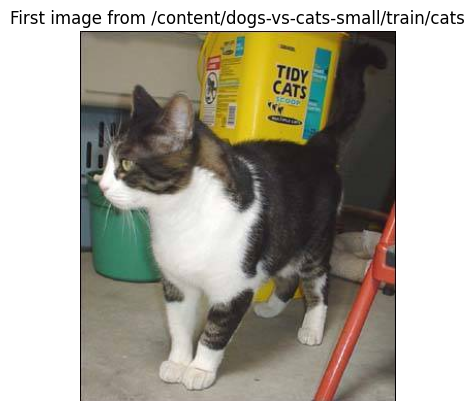

the image has shape: (359, 306, 3)
example of rescaled data: [0.02745098 0.         0.        ]


In [5]:
# BELOW IS FOR ONE IMAGE ONLY, TO TEST THE PREPROCESSING STEPS

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import os
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras import layers

# read / open image files

cat_images_dir = os.path.join(train_dir, 'cats')
cat_image_filenames = os.listdir(cat_images_dir)

# test by displaying the first image

first_cat_image_name = cat_image_filenames[0]
first_cat_image_path = os.path.join(cat_images_dir, first_cat_image_name)
first_img = load_img(first_cat_image_path)
plt.imshow(first_img)
plt.title(f"First image from {cat_images_dir}")
plt.axis('off')
plt.show()

# decode to RGB grid of pixels

rgb_img = first_img.convert('RGB')
rgb_data = np.array(rgb_img)
print(f'the image has shape: {rgb_data.shape}')

# rescale pixel values to between 0 and 1

rescaled_image = rgb_data / 255
print(f'example of rescaled data: {rescaled_image[0][0]}')

In [6]:
# SET UP PREPROCESSING AND DATA AUGMENTATION

IMG_WIDTH = 180
IMG_HEIGHT = 180
BATCH_SIZE = 32 # You can adjust this batch size

# Create a preprocessing layer to resize and rescale images
resize_and_rescale = tf.keras.Sequential([
  tf.keras.layers.Resizing(IMG_WIDTH, IMG_HEIGHT),
  tf.keras.layers.Rescaling(1./255)
])

# DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

In [7]:
# NOW APPLYING PREPROCESSING TO ALL THE DATASETS

# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, # This should be your '/content/dogs-vs-cats-small/train' directory
    labels='inferred',
    label_mode='binary', # For binary classification (dogs vs cats)
    image_size=(IMG_WIDTH, IMG_HEIGHT),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True # Shuffle training data
)

# Load validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='binary', # For binary classification (dogs vs cats)
    image_size=(IMG_WIDTH, IMG_HEIGHT),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True # Shuffle training data
)

# Load test data
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='binary', # For binary classification (dogs vs cats)
    image_size=(IMG_WIDTH, IMG_HEIGHT),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True # Shuffle training data
)

# When preprocessing layers are part of the model (Option 1), datasets should not apply them separately.
# The model itself will handle the resizing and rescaling for all inputs.
# Data augmentation is applied by the model only to training data.

print("Datasets loaded successfully:")

# Optionally, you can prefetch data for better performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Datasets loaded successfully:


## STEP 1: Build the CNN network
Use the same small convnet in `dogs_vs_cats.ipynb`. **Don't add any other regularization** techniques (such as dropout), as you will know any performance changes in this experiment is purely because of data augmentation.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     5,308,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,550,273 (21.17 MB)

 Trainable params: 5,550,273 (21.17 MB)

 Non-trainable params: 0 (0.00 B)

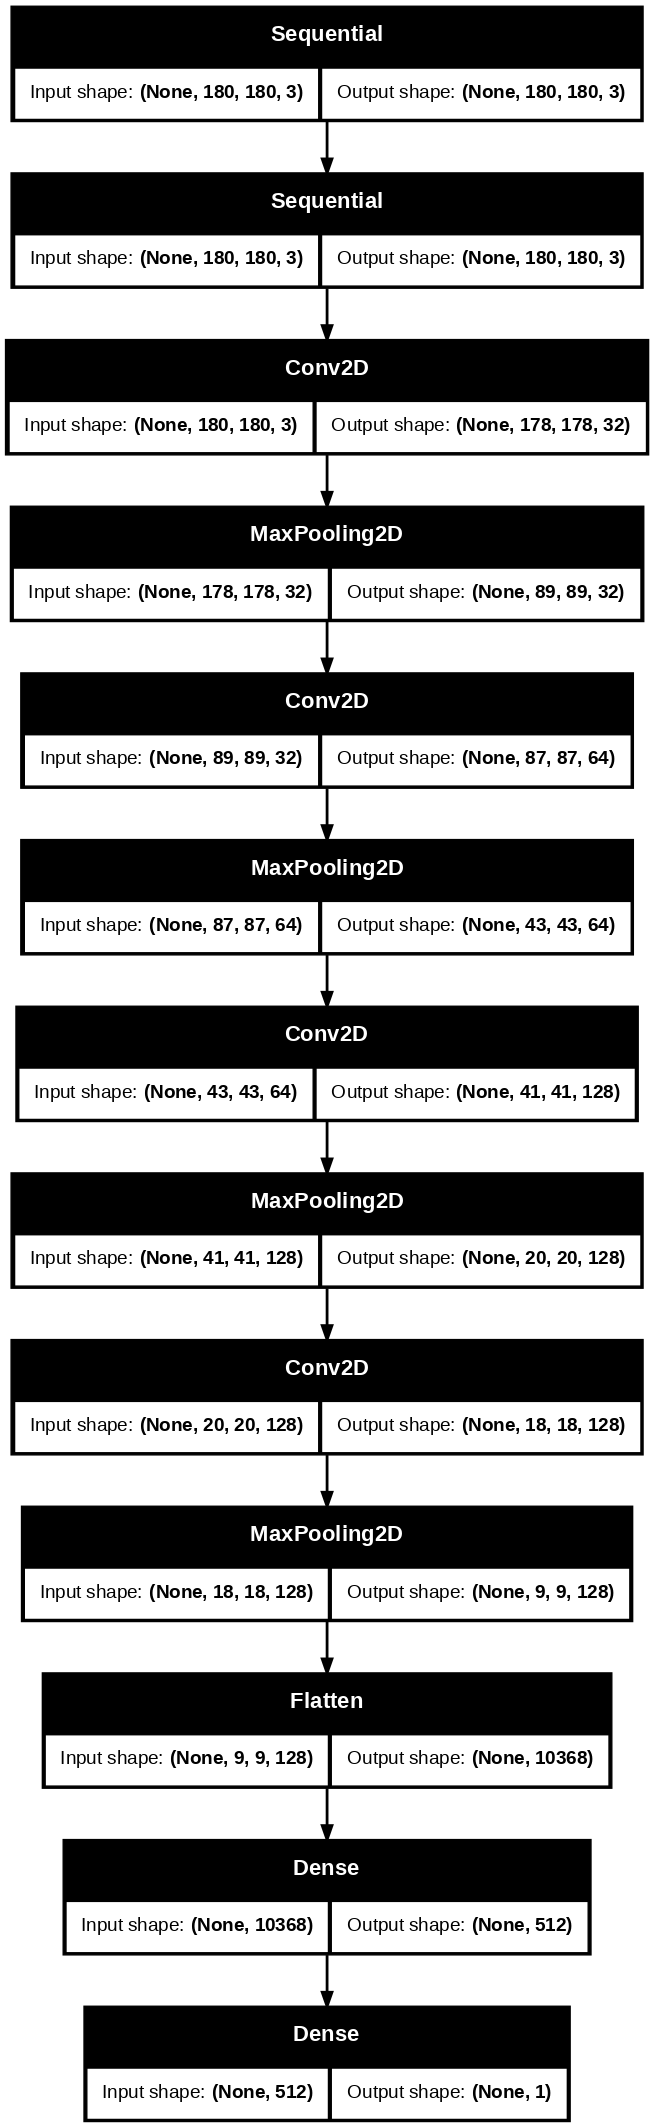

In [9]:
# OPTION 1 - BUILDING THE MODEL WITH THE PREPROCESSING AND AUGMENTATION BUILT IN

model = tf.keras.Sequential([
  layers.Input(shape=(180,180,3)),
  resize_and_rescale,
  data_augmentation,
  layers.Conv2D(32, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(64, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(128, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(128, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(512, activation='relu'),
  layers.Dense(1, activation='sigmoid'),
])

model.summary()
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True, dpi=100) # visualize the CNN artitecture

## STEP 2: Compile the model
The typical loss function for a binary classification problem is the binary cross-entropy loss function.

In [10]:
model.compile(loss='binary_crossentropy',
            optimizer='adam',#adam (with default parameters) is always a good choice
            metrics=['accuracy'])

## STEP 4: Train the model and draw learning curves
Let's train the model. You may need more epochs in this training, say `epochs=120`.

It is a good practice to always save your models after training with `model.save_model(model_folder+'/dogs_cats_small_data_augment.keras') `.

After training, also plot the loss and accuracy of the model over the training and validation set.

Epoch 1/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 150ms/step - accuracy: 0.5250 - loss: 0.6958 - val_accuracy: 0.5010 - val_loss: 0.7288
Epoch 2/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5800 - loss: 0.6745 - val_accuracy: 0.5490 - val_loss: 0.7107
Epoch 3/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.6055 - loss: 0.6557 - val_accuracy: 0.5220 - val_loss: 0.7456
Epoch 4/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6105 - loss: 0.6573 - val_accuracy: 0.6340 - val_loss: 0.6628
Epoch 5/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.6680 - loss: 0.6034 - val_accuracy: 0.6440 - val_loss: 0.6348
Epoch 6/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6755 - loss: 0.5925 - val_accuracy: 0.6220 - val_loss: 0.6336
Epoch 7/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6725 - loss: 0.5918 - val_accuracy: 0.6610 - val_loss: 0.6097
Epoch 8/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7040 - loss: 0.5687 - val_accuracy: 

Text(0.5, 0, 'epoch')

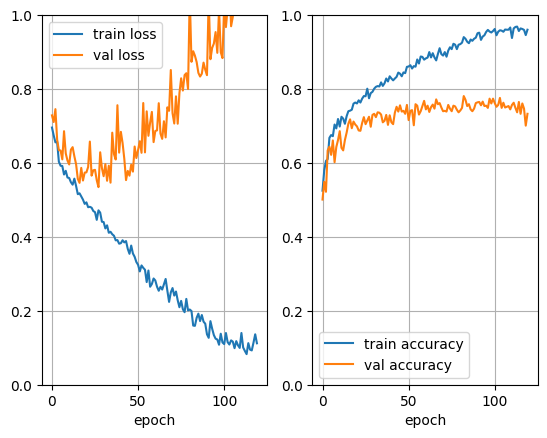

In [11]:
# Train the model

epochs = 120
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

model_folder = '/content/drive/My Drive/MSc_AI/Unit9_ADL/models'
import os
if not os.path.exists(model_folder):
    os.mkdir(model_folder)
model.save(model_folder+'/dogs_cats_small_data_augment_option1_baseline.keras')  # always save your model after training

# plot the learning curves
import matplotlib.pyplot as plt
fig = plt.figure()
fig.add_subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.grid(True)
plt.ylim([0,1.0])
plt.xlabel('epoch')

fig.add_subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0,1.0])
plt.xlabel('epoch')

**Q:** According to your learning curve, is the overfitting problem solved with data augmentation? Is there any accuracy improvement?  

**Optional:** After successfully completing data augmentation, you can fine-tune the network’s parameters or incorporate additional regularization techniques, such as dropout, early stopping, weight regularization, or batch normalization, to further improve accuracy.


